# An Introduction to Word Embeddings

# Download Libraries to perform NLP Related task

In [3]:
! pip install spacy csv

ERROR: Could not find a version that satisfies the requirement csv (from versions: none)

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for csv


## Training Word Embeddings 

In [4]:
import os
import csv
import spacy
import gensim


In [5]:


class Corpus(object):
    def __init__(self, filename):
        self.filename = filename
        self.nlp = spacy.blank("en")

    def __iter__(self):
        with open(self.filename, "r", encoding="utf-8") as f:
            reader = csv.reader(f, delimiter=",")
            for row in reader:
                if not row:
                    continue
                # assume abstract is in second column if present, otherwise use first
                abstract = row[1] if len(row) > 1 else row[0]
                tokens = [t.text.lower() for t in self.nlp(abstract)]
                yield tokens

# Notebook is in Day-2/, arxiv.csv is in the repository root — use relative path
documents = Corpus("../arxiv.csv")

In [6]:
documents = list(documents)
documents[:10]

[['this',
  'paper',
  'investigates',
  'a',
  'cross',
  '-',
  'lingual',
  'document',
  'embedding',
  'method',
  'that',
  '\n',
  'improves',
  'the',
  'current',
  'neural',
  'machine',
  'translation',
  'framework',
  'based',
  'document',
  'vector',
  '\n',
  '(',
  'ntdv',
  'or',
  'simply',
  'nv',
  ')',
  '.',
  'nv',
  'is',
  'developed',
  'with',
  'a',
  'self',
  '-',
  'attention',
  'mechanism',
  'under',
  'the',
  '\n',
  'neural',
  'machine',
  'translation',
  '(',
  'nmt',
  ')',
  'framework',
  '.',
  'in',
  'nv',
  ',',
  'each',
  'pair',
  'of',
  'parallel',
  '\n',
  'documents',
  'in',
  'different',
  'languages',
  'are',
  'projected',
  'to',
  'the',
  'same',
  'shared',
  'layer',
  'in',
  'the',
  '\n',
  'model',
  '.',
  'however',
  ',',
  'the',
  'pair',
  'of',
  'nv',
  'embeddings',
  'are',
  'not',
  'guaranteed',
  'to',
  'be',
  'similar',
  '.',
  '\n',
  'this',
  'paper',
  'further',
  'adds',
  'a',
  'distance',


In [7]:
model = gensim.models.Word2Vec(documents, vector_size=100, window=5, min_count=100)

In [9]:
model.wv["nlp"]

array([ 3.9097047e-01, -2.1189659e+00,  2.6696045e+00, -4.3403682e-01,
        3.2717830e-01,  5.9164375e-01,  2.3354285e+00,  4.9536315e-01,
       -5.4930967e-01,  2.1793239e+00, -1.6815110e+00, -1.3442862e+00,
        1.9569507e+00, -4.0922335e-01,  5.9760511e-01,  4.8466134e-01,
       -2.2287022e-01,  4.9252620e-01, -3.6615258e-01,  2.2838259e+00,
        1.0045561e+00, -3.2182958e-03,  4.3319049e-01,  2.0811017e-01,
       -1.8387333e+00, -2.4327035e+00,  1.5022103e+00, -5.5606955e-01,
        2.3552163e+00,  3.7772813e-01, -4.6087253e-01,  8.3372772e-01,
        3.5893151e-01,  1.0475563e+00,  2.1854489e+00, -2.5866826e+00,
        1.3171277e+00, -4.6470242e+00, -5.3690290e-01,  2.3480663e+00,
       -6.6160750e-01,  5.2333526e-02,  2.9699531e+00,  1.2281775e+00,
       -1.3560222e+00, -5.4232258e-02,  2.1626790e+00,  1.0341443e+00,
        4.8436615e-01, -7.4771506e-01,  1.0819308e+00,  1.3629179e+00,
        1.2187995e+00, -2.2742383e-01, -1.8155843e-01,  3.5283692e-02,
      

In [8]:
print(model.wv.similarity("nmt", "smt"))
print(model.wv.similarity("nmt", "ner"))

0.66688925
0.38041335


In [10]:
model.wv.most_similar(positive=["tree"], topn = 10)

[('trees', 0.7650451064109802),
 ('constituency', 0.7297025322914124),
 ('parse', 0.6839531064033508),
 ('dependency', 0.6260145306587219),
 ('recursive', 0.615057647228241),
 ('constituent', 0.6130226254463196),
 ('parser', 0.594759464263916),
 ('syntax', 0.5873589515686035),
 ('transition', 0.5765379667282104),
 ('hierarchical', 0.5759410858154297)]

In [11]:
print(model.wv.doesnt_match("lstm cnn gru svm transformer".split()))
print(model.wv.doesnt_match("bert word2vec gpt-2 roberta xlnet".split()))
print(model.wv.doesnt_match("word2vec bert glove fasttext elmo".split()))

svm
word2vec
bert


# Plotting Embedding

In [15]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE

target_word = "bert"
selected_word = [w[0] for w in model.wv.most_similar(target_word, topn=200)] + [target_word]
embeddings = [model.wv[w] for w in selected_word] +  model.wv["bert"]

mapped_embeddings = TSNE(n_components=2, metric = 'cosine',  init = 'pca') . fit_transform(embeddings)

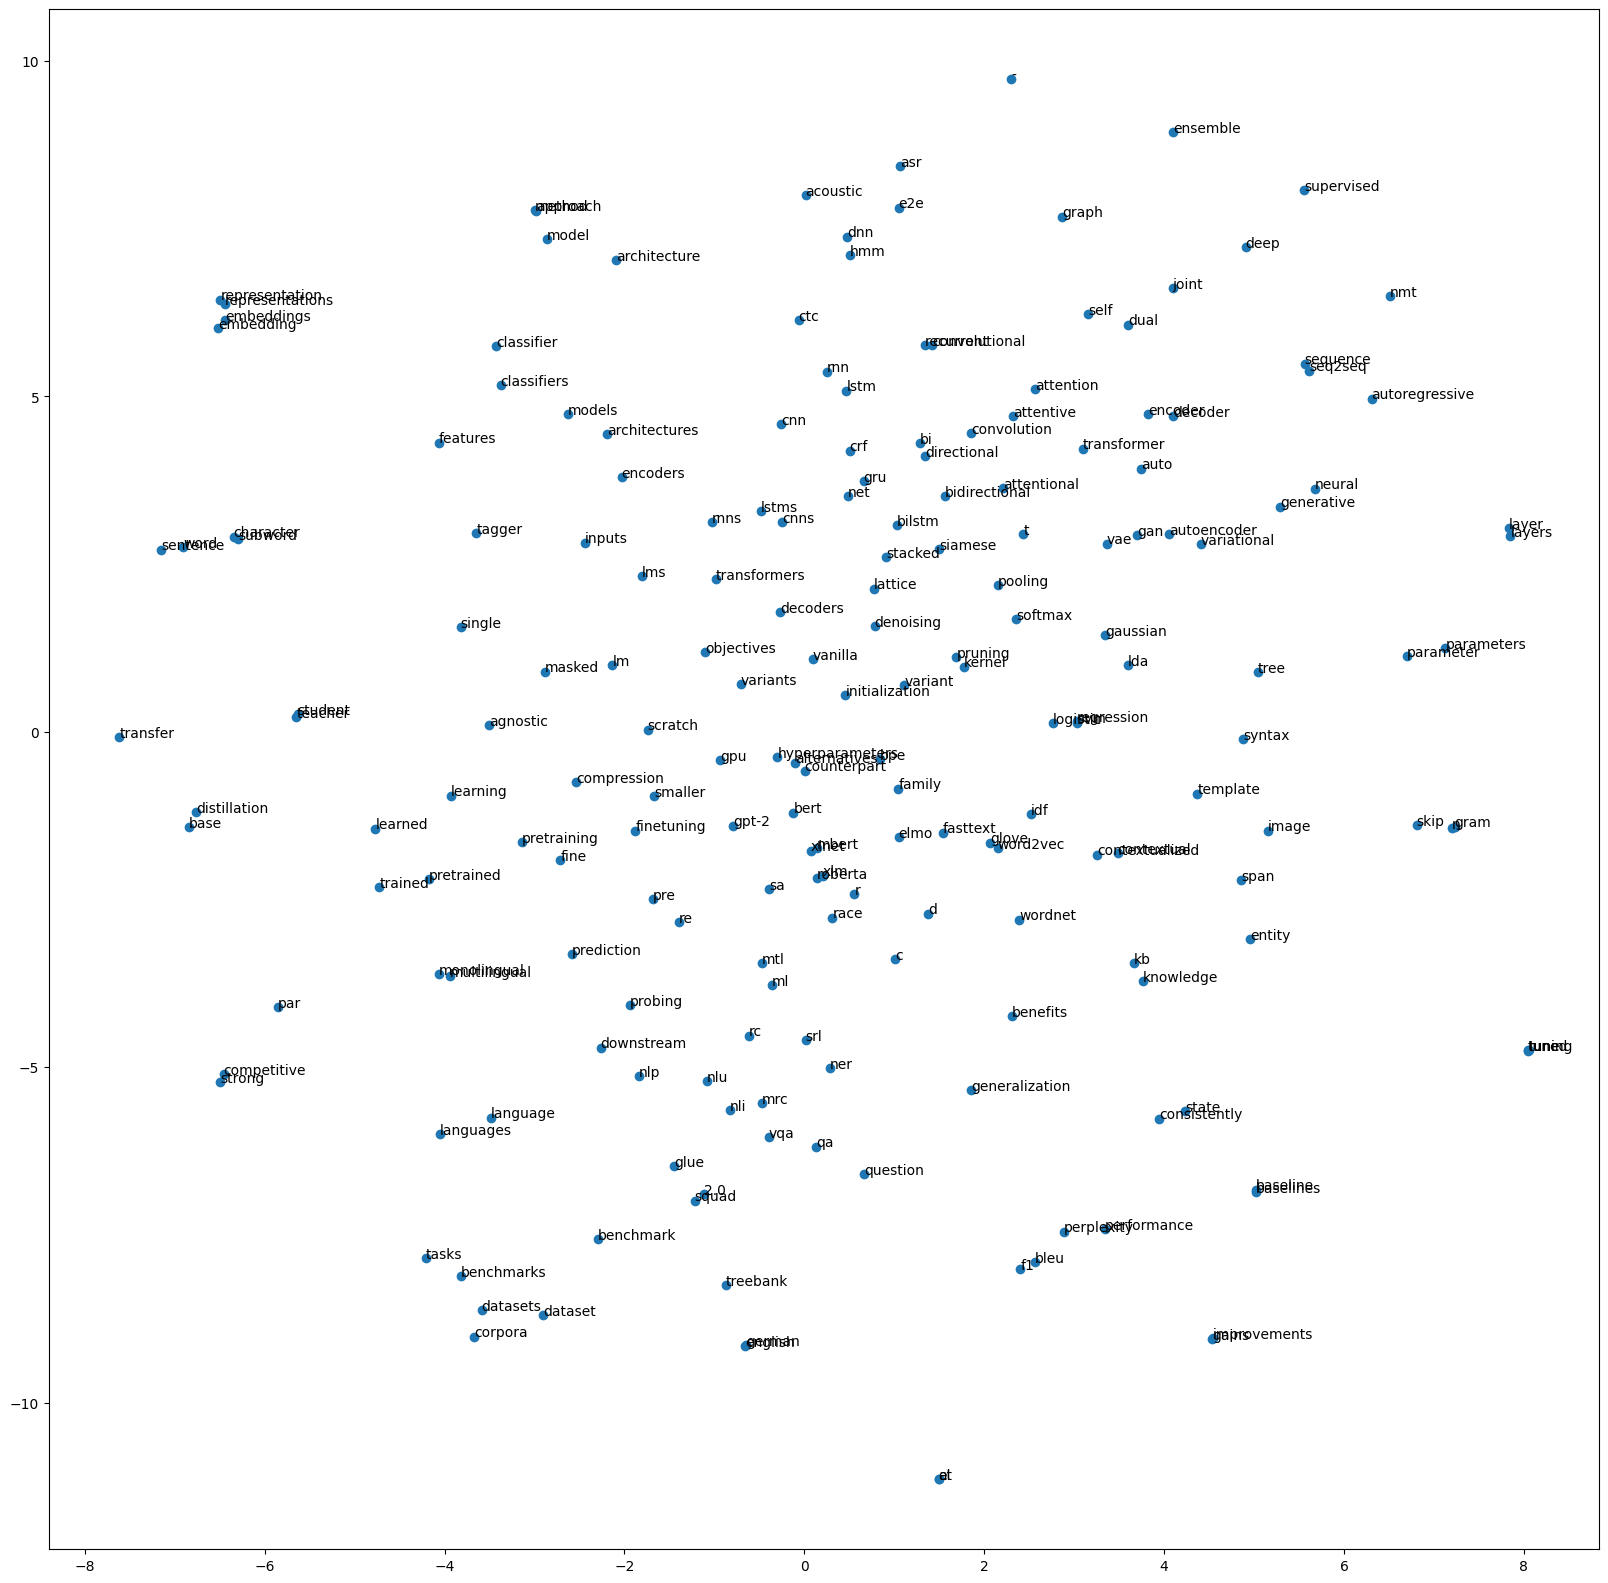

In [16]:
plt.figure(figsize=(20,20))
x = mapped_embeddings[:,0]
y = mapped_embeddings[:,1]
plt.scatter(x, y)

for i, txt in enumerate(selected_word):
    plt.annotate(txt, (x[i], y[i]))